# Praktikum 4: Penerapan Template Matching

Praktikum ini menerapkan pencocokan template untuk menemukan lokasi objek kecil (template) dalam citra yang lebih besar.

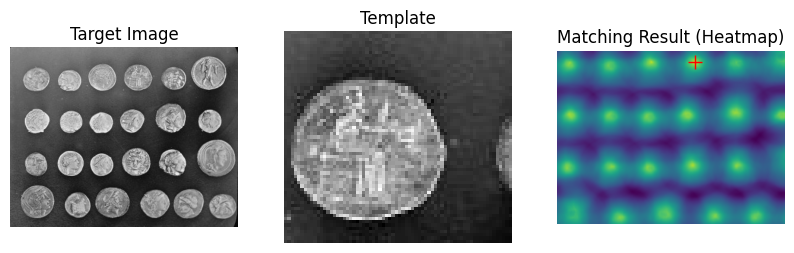

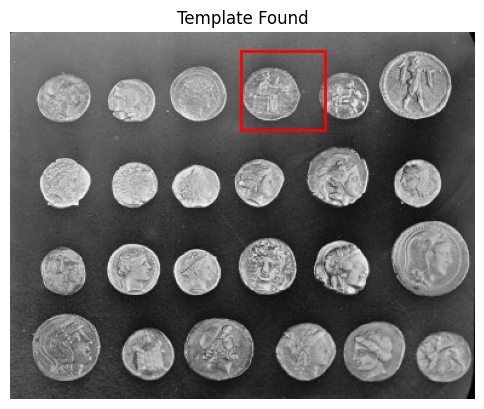

Template ditemukan di koordinat (x,y): (190, 15)
Skor kecocokan maksimum: 1.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan buat/muat citra template
image = data.coins()
template = image[15:80, 190:260]

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()
ax[2].plot(x, y, 'r+', markersize=10)

fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")
print(f"Skor kecocokan maksimum: {result.max():.4f}")

### Hasil Praktikum 4
Area paling terang pada heatmap sesuai dengan lokasi template pada citra asli. Template berhasil ditemukan, tetapi metode ini tidak invariant terhadap rotasi dan perubahan skala.